# Energy Cost Optimization for European Countries
### YZV202E — Optimization for Data Science
**Authors:** Ahmet Selim Bayram · Omar Qawasmi · Emre Günel

Istanbul Technical University — Artificial Intelligence and Data Engineering

---

## Project Overview

This notebook implements a **Linear Programming (LP)** model to determine the minimum-cost
electricity generation mix for 7 European countries (Germany, France, Turkey, Spain, Italy,
Poland, Netherlands) over the period 2015–2023.

**Decision variable:** $x_i$ — annual electricity generated from source $i$ (GWh)

**Objective:**
$$\min_x \sum_{i \in S} \bigl(\text{LCOE}_i + C_{\text{CO}_2} \cdot E_i\bigr)\, x_i$$

**Constraints:**
$$\sum_{i \in S} x_i = D \qquad (\text{demand must be met})$$
$$0 \leq x_i \leq K_i \cdot \text{AF}_i \cdot 8760 \qquad (\text{capacity upper bound})$$

where $S = \{\text{coal, gas, nuclear, hydro, wind, solar}\}$

**Extended analysis:** the same LP is also solved with `scipy.optimize.linprog` and the
two solvers are benchmarked for time and solution quality.

## 0. Setup

In [2]:
!pip install pulp ipywidgets matplotlib numpy pandas scipy cvxpy --quiet

#from google.colab import output
#output.enable_custom_widget_manager()

import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp
import scipy.optimize as opt
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.0 MB/s eta 0:00:00
✅ All libraries loaded.


## 1. Fixed Parameters

### 1-A. Energy Sources & Styling

In [3]:
SOURCES       = ['coal', 'gas', 'nuclear', 'hydro', 'wind', 'solar']
SOURCE_LABELS = ['Coal', 'Natural Gas', 'Nuclear', 'Hydropower', 'Wind', 'Solar']
SOURCE_COLORS = ['#2b2b2b', '#d95f02', '#7570b3', '#1f78b4', '#2ca02c', '#ffd92f']

YEARS = list(range(2015, 2024))

### 1-B. Year-Specific LCOE ($/MWh)
Source: Lazard's Levelized Cost of Energy Analysis (annual editions, 2015–2023)

In [4]:
LCOE_HISTORY = {
    2015: {'coal': 108.0, 'gas':  65.0, 'nuclear': 117.0, 'hydro': 40.0, 'wind': 55.0, 'solar':  64.0},
    2016: {'coal': 102.0, 'gas':  63.0, 'nuclear': 117.0, 'hydro': 50.0, 'wind': 47.0, 'solar':  55.0},
    2017: {'coal': 102.0, 'gas':  60.0, 'nuclear': 148.0, 'hydro': 50.0, 'wind': 45.0, 'solar':  50.0},
    2018: {'coal': 102.0, 'gas':  58.0, 'nuclear': 151.0, 'hydro': 40.0, 'wind': 42.0, 'solar':  43.0},
    2019: {'coal': 109.0, 'gas':  56.0, 'nuclear': 155.0, 'hydro': 40.0, 'wind': 40.0, 'solar':  41.0},
    2020: {'coal': 112.0, 'gas':  59.0, 'nuclear': 163.0, 'hydro': 50.0, 'wind': 40.0, 'solar':  40.0},
    2021: {'coal': 108.0, 'gas':  60.0, 'nuclear': 167.0, 'hydro': 50.0, 'wind': 38.0, 'solar':  38.0},
    2022: {'coal': 117.0, 'gas':  70.0, 'nuclear': 180.0, 'hydro': 60.0, 'wind': 50.0, 'solar':  60.0}, # Since 2022 data was not available on Lazard, 2023 was used.
    2023: {'coal': 117.0, 'gas':  70.0, 'nuclear': 180.0, 'hydro': 60.0, 'wind': 50.0, 'solar':  60.0},
}

### 1-C. CO₂ Intensity (ton CO₂/MWh)
Source: World Nuclear Association lifecycle emission factors

In [5]:
CO2_INTENSITY = {
    'coal':    0.820,
    'gas':     0.490,
    'nuclear': 0.120,
    'hydro':   0.240,
    'wind':    0.110,
    'solar':   0.480,
}

### 1-D. EU ETS Carbon Price ($/ton)
Source: International Carbon Action Partnership (ICAP), annual average

In [6]:
CARBON_PRICE_HIST = {
    2015:  8.45, 2016:  5.62, 2017:  6.55, 2018: 18.18,
    2019: 27.66, 2020: 27.90, 2021: 63.74, 2022: 84.42, 2023: 90.36,
}

### 1-E. Availability Factors (AF)
Source: U.S. Department of Energy / Energy Information Administration (2024).
AF represents the fraction of installed capacity realistically available for dispatch,
accounting for planned outages, seasonal variability, and fuel supply constraints.

In [7]:
# These are used as the upper-bound constraint in the LP.
BASE_AF = {
    'coal':    0.426,
    'gas':     0.599,   # combined cycle
    'nuclear': 0.923,
    'hydro':   0.345,
    'wind':    0.343,
    'solar':   0.234,
}

## 2. Data Preparation & Processing

Three Eurostat datasets are used:

| Variable | Dataset | Filter |
|---|---|---|
| Demand $D$ (GWh) | `nrg_cb_e` | `nrg_bal = FC` (final consumption) |
| Installed capacity $K_i$ (MW → GW) | `nrg_inf_epc` | `operator = TOTAL` |
| Generation $P_i$ (GWh) | `nrg_bal_peh_filtered` | `unit = GWH`, source-level |

> **Note on `nrg_bal_peh`:** The full Eurostat generation dataset is ~700 MB.
> It was pre-filtered locally (countries, years, source-level SIEC codes, unit = GWH)
> and saved as `nrg_bal_peh_filtered.csv` before being used here.

**Key data challenges:**
- Eurostat reports coal + gas capacity jointly under SIEC code `CF` (combustible fuels).
  We decompose this using each year's observed coal/gas generation shares.

In [8]:
PATH_DEMAND    = 'nrg_cb_e_linear_2_0.csv'
PATH_CAPACITY  = 'nrg_inf_epc_linear_2_0.csv'
PATH_PROD_FILT = 'nrg_bal_peh_filtered.csv'

COUNTRIES  = ['DE', 'FR', 'TR', 'ES', 'IT', 'PL', 'NL']
GEO_TO_NAME = {
    'DE': 'Germany', 'FR': 'France',  'TR': 'Turkey',
    'ES': 'Spain',   'IT': 'Italy',   'PL': 'Poland', 'NL': 'Netherlands',
}

# ── 2-A. Demand ───────────────────────────────────────────────────────────────
raw_dem = pd.read_csv(PATH_DEMAND)
dem = (
    raw_dem[
        (raw_dem['nrg_bal'] == 'FC') &
        (raw_dem['geo'].isin(COUNTRIES)) &
        (raw_dem['TIME_PERIOD'].between(2015, 2023))
    ]
    [['geo', 'TIME_PERIOD', 'OBS_VALUE']]
    .rename(columns={'TIME_PERIOD': 'year', 'OBS_VALUE': 'demand_GWh'})
    .dropna(subset=['demand_GWh'])
    .reset_index(drop=True)
)
print('✅ Demand loaded.')
print(dem.pivot(index='year', columns='geo', values='demand_GWh').round(0).to_string())

✅ Demand loaded.
geo         DE        ES        FR        IT        NL        PL        TR
year                                                                      
2015  528350.0  238545.0  442137.0  297180.0  109527.0  138927.0  217313.0
2016  530551.0  239821.0  450663.0  295509.0  110652.0  143762.0  231204.0
2017  531318.0  246542.0  446863.0  301881.0  111558.0  146425.0  249023.0
2018  521809.0  245769.0  445052.0  303443.0  113713.0  151398.0  258232.0
2019  507543.0  242165.0  439293.0  301804.0  113385.0  152002.0  257273.0
2020  492821.0  227172.0  419199.0  283815.0  111400.0  148241.0  262702.0
2021  510100.0  235025.0  440545.0  300887.0  112602.0  157313.0  286691.0
2022  487539.0  231847.0  423358.0  295840.0  108386.0  153207.0  286576.0
2023  473497.0  229771.0  407334.0  287361.0  106248.0  147582.0  289372.0


In [9]:
# ── 2-B. Installed Capacity ───────────────────────────────────────────────────
SIEC_CAP_MAP = {
    'CF':    'combustible_fuels',
    'N9000': 'nuclear',
    'RA100': 'hydro',
    'RA300': 'wind',
    'RA420': 'solar',
}

raw_cap = pd.read_csv(PATH_CAPACITY)
cap_raw = (
    raw_cap[
        (raw_cap['operator'] == 'TOTAL') &
        (raw_cap['geo'].isin(COUNTRIES)) &
        (raw_cap['TIME_PERIOD'].between(2015, 2023))
    ]
    [['geo', 'TIME_PERIOD', 'siec', 'OBS_VALUE']]
    .rename(columns={'TIME_PERIOD': 'year', 'OBS_VALUE': 'value_MW'})
    .dropna(subset=['value_MW'])
)

cap = cap_raw[cap_raw['siec'].isin(SIEC_CAP_MAP)].copy()
cap['source']      = cap['siec'].map(SIEC_CAP_MAP)
cap                = cap.groupby(['geo', 'year', 'source'], as_index=False)['value_MW'].max()
cap['capacity_GW'] = cap['value_MW'] / 1000

print('✅ Capacity loaded — Germany example:')
print(cap[cap['geo'] == 'DE'].pivot(index='year', columns='source', values='capacity_GW').round(2).to_string())

✅ Capacity loaded — Germany example:
source  combustible_fuels  hydro  nuclear  solar   wind
year                                                   
2015                96.97  11.26    10.80  39.22  44.58
2016                95.72  11.21    10.80  40.68  49.44
2017                95.13  11.12    10.80  42.29  55.58
2018               103.03  10.68    10.80  45.16  58.72
2019               100.52  10.73     9.52  48.91  60.74
2020                98.31  10.81     8.11  53.67  62.20
2021                99.24  10.84     8.11  60.04  63.71
2022               100.87  10.92     4.20  61.19  66.20
2023               100.43  10.95     4.20  75.52  69.44


In [10]:
# ── 2-C. Generation (source-level) ────────────────────────────────────────────
raw_prod = pd.read_csv(PATH_PROD_FILT)
prod_src = (
    raw_prod[raw_prod['unit'] == 'GWH']
    [['geo', 'TIME_PERIOD', 'source', 'OBS_VALUE']]
    .rename(columns={'TIME_PERIOD': 'year', 'OBS_VALUE': 'prod_GWh'})
    .dropna(subset=['prod_GWh'])
)
prod_pv = (prod_src.pivot_table(index=['geo', 'year'], columns='source',
                                values='prod_GWh', aggfunc='sum')
           .reset_index())

print('✅ Generation loaded.')
print(prod_pv[prod_pv['geo'] == 'DE'][['year', 'wind', 'solar', 'coal']].set_index('year').T.to_string())

✅ Generation loaded.
year        2015      2016      2017      2018      2019      2020      2021        2022      2023
source                                                                                            
wind     80624.0   79924.0  105693.0  109951.0  125894.0  132102.0  114169.0  124816.000  141764.0
solar    38726.0   38098.0   39401.0   43459.0   44383.0   49496.0   50472.0   61022.000   64299.0
coal    272200.0  261745.0  241254.0  228156.0  171450.0  134595.0  164651.0  179948.015  124786.0


In [11]:
# ── 2-D. Build COUNTRY_DATA ───────────────────────────────────────────────────
# Coal/gas capacity split: use generation-based shares since Eurostat
# reports them jointly under "combustible fuels" (SIEC: CF).

def get_coal_ratio(geo, year):
    row = prod_pv[(prod_pv['geo'] == geo) & (prod_pv['year'] == year)]
    if row.empty:
        return 0.5
    c = float(row['coal'].values[0]) if 'coal' in row.columns and not pd.isna(row['coal'].values[0]) else 0.0
    g = float(row['gas'].values[0])  if 'gas'  in row.columns and not pd.isna(row['gas'].values[0])  else 0.0
    total = c + g
    return (c / total) if total > 0 else 0.5

def _get_cap(geo, year, source):
    r = cap[(cap['geo'] == geo) & (cap['year'] == year) & (cap['source'] == source)]
    return float(r['capacity_GW'].values[0]) if not r.empty else 0.0

def _get_prod(geo, year, source):
    r = prod_pv[(prod_pv['geo'] == geo) & (prod_pv['year'] == year)]
    if r.empty or source not in r.columns:
        return 0.0
    val = r[source].values[0]
    return float(val) if not pd.isna(val) else 0.0

COUNTRY_DATA = {}
for geo, name in GEO_TO_NAME.items():
    COUNTRY_DATA[name] = {}
    for year in YEARS:
        d_row  = dem[(dem['geo'] == geo) & (dem['year'] == year)]
        demand = float(d_row['demand_GWh'].values[0]) if not d_row.empty else np.nan
        K_cf   = _get_cap(geo, year, 'combustible_fuels')
        cr     = get_coal_ratio(geo, year)
        COUNTRY_DATA[name][year] = {
            'demand_GWh': demand,
            'capacity_GW': {
                'coal':    K_cf * cr,
                'gas':     K_cf * (1 - cr),
                'nuclear': _get_cap(geo, year, 'nuclear'),
                'hydro':   _get_cap(geo, year, 'hydro'),
                'wind':    _get_cap(geo, year, 'wind'),
                'solar':   _get_cap(geo, year, 'solar'),
            },
            'production_GWh': {s: _get_prod(geo, year, s) for s in SOURCES},
            '_coal_ratio': round(cr, 3),
        }

print('✅ COUNTRY_DATA ready.')
print(f'   Countries: {list(COUNTRY_DATA.keys())}')
print(f'   Years    : {YEARS}')

✅ COUNTRY_DATA ready.
   Countries: ['Germany', 'France', 'Turkey', 'Spain', 'Italy', 'Poland', 'Netherlands']
   Years    : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


### 2-E. Exploratory Visualization

Before modelling, we inspect how demand and carbon price evolved over time —
the two key drivers of the optimization outcome.

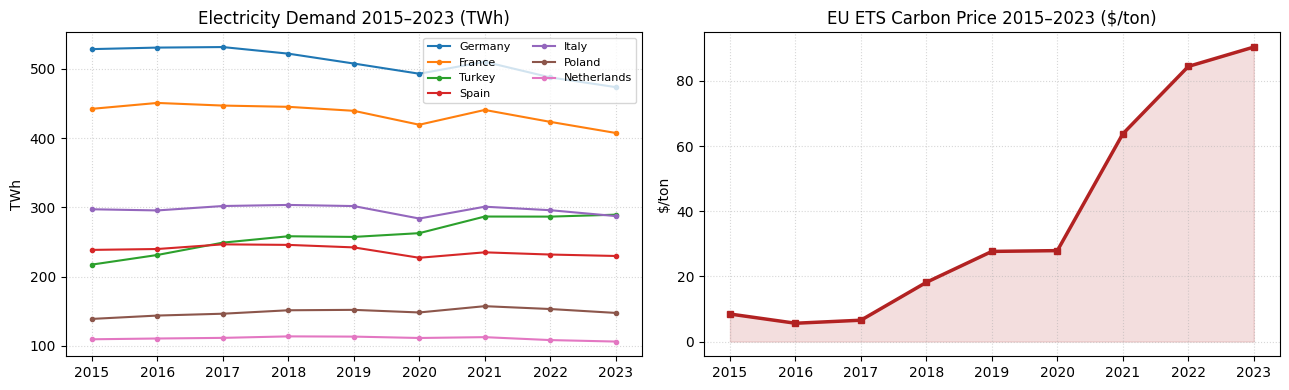

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Demand trends
ax = axes[0]
for name in COUNTRY_DATA:
    vals = [COUNTRY_DATA[name][y]['demand_GWh'] / 1e3 for y in YEARS]
    ax.plot(YEARS, vals, marker='o', markersize=3, label=name)
ax.set_title('Electricity Demand 2015–2023 (TWh)')
ax.set_ylabel('TWh')
ax.legend(fontsize=8, ncol=2)
ax.grid(linestyle=':', alpha=0.5)

# Carbon price
ax = axes[1]
ax.plot(YEARS, [CARBON_PRICE_HIST[y] for y in YEARS],
        color='firebrick', linewidth=2.5, marker='s', markersize=5)
ax.fill_between(YEARS, [CARBON_PRICE_HIST[y] for y in YEARS], alpha=0.15, color='firebrick')
ax.set_title('EU ETS Carbon Price 2015–2023 ($/ton)')
ax.set_ylabel('$/ton')
ax.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 3. LP Model & Solution (PuLP / CBC Simplex)

The solver minimises total generation cost subject to demand balance and
capacity constraints. Unit cost for source $i$:
$$c_i = \text{LCOE}_i \cdot m_i^{\text{lcoe}} + C_{\text{CO}_2} \cdot m_i^{\text{carbon}} \cdot E_i \quad [\$/\text{MWh}]$$

The objective is scaled to GWh: $\min \sum_i c_i \cdot 1000 \cdot x_i$

In [13]:
def solve_lp(country, year, af, lcoe_mult, carbon_mult):
    """
    Solve LP dispatch for a given country and year.

    Parameters
    ----------
    country      : str
    year         : int
    af           : dict  — availability factors per source
    lcoe_mult    : dict  — LCOE multipliers (1.0 = baseline)
    carbon_mult  : dict  — carbon cost multipliers (1.0 = baseline)

    Returns
    -------
    dict with keys: optimal_GWh, unit_cost, total_cost_M, marginal_cost,
                    upper_GWh, status, solve_time_ms
    """
    data  = COUNTRY_DATA[country][year]
    D     = data['demand_GWh']

    # Upper bounds: K_i (GW) × AF_i × 8760 h/yr = max GWh
    upper = {s: data['capacity_GW'][s] * 8760 * af[s] for s in SOURCES}

    # Unit cost $/MWh — both LCOE and carbon term share same unit
    cost = {
        s: LCOE_HISTORY[year][s] * lcoe_mult[s]
           + CARBON_PRICE_HIST[year] * carbon_mult[s] * CO2_INTENSITY[s]
        for s in SOURCES
    }

    prob = pulp.LpProblem('dispatch', pulp.LpMinimize)
    x    = {s: pulp.LpVariable(s, 0, upper[s]) for s in SOURCES}

    # Objective scaled: $/MWh × 1000 MWh/GWh × GWh = $
    prob += pulp.lpSum(cost[s] * 1000 * x[s] for s in SOURCES)
    prob += pulp.lpSum(x[s] for s in SOURCES) == D, 'demand'

    t0 = time.perf_counter()
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    elapsed_ms = (time.perf_counter() - t0) * 1000

    optimal   = {s: pulp.value(x[s]) or 0.0 for s in SOURCES}
    total_gen = sum(optimal.values())
    total_usd   = pulp.value(prob.objective) or 0.0

    return {
        'status':        pulp.LpStatus[prob.status],
        'optimal_GWh':   optimal,
        'unit_cost':     cost,                           # $/MWh
        'upper_GWh':     upper,
        'total_cost_M':  total_usd / 1e6,                 # M$
        'marginal_cost': total_usd / (total_gen * 1e3) if total_gen > 0 else 0,  # $/MWh
        'solve_time_ms': elapsed_ms,
    }

print("✅ solve_lp (PuLP) defined.")

✅ solve_lp (PuLP) defined.


### 3-A. Result Visualization

In [14]:
def plot_results(result, country, year):
    """3-panel figure: optimal vs historical generation, unit costs, generation mix."""

    hist  = COUNTRY_DATA[country][year]['production_GWh']
    opt   = result['optimal_GWh']
    cost  = result['unit_cost']
    upper = result['upper_GWh']
    x_pos = np.arange(len(SOURCES))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"LP Optimization — {country} {year}  |  Status: {result['status']}\n"
        f"Total Cost: {result['total_cost_M']:.1f} M$  |  "
        f"Marginal: {result['marginal_cost']:.2f} $/MWh  |  "
        f"Carbon: {CARBON_PRICE_HIST[year]:.2f} $/ton",
        fontsize=12, fontweight='bold'
    )

    # Panel 1 — Optimal vs Historical
    ax = axes[0]
    ax.bar(x_pos - 0.2, [opt[s]/1e3  for s in SOURCES], 0.35,
           color=SOURCE_COLORS, alpha=0.95, edgecolor='black', linewidth=0.5, label='LP Optimal')
    ax.bar(x_pos + 0.2, [hist[s]/1e3 for s in SOURCES], 0.35,
           color=SOURCE_COLORS, alpha=0.35, edgecolor='black', linewidth=0.5,
           hatch='//', label='Historical')
    for i, s in enumerate(SOURCES):
        ax.hlines(upper[s]/1e3, i-0.38, i+0.38, colors='red', linestyles='--', linewidth=1.2)
    ax.set_xticks(x_pos); ax.set_xticklabels(SOURCE_LABELS, rotation=20, ha='right')
    ax.set_ylabel('Generation (TWh)')
    ax.set_title('Optimal vs Historical Generation')
    cap_ln = plt.Line2D([0],[0], color='red', linestyle='--', label='Capacity limit')
    ax.legend(handles=[plt.Rectangle((0,0),1,1,fc='#555',alpha=0.95,ec='k'),
                        plt.Rectangle((0,0),1,1,fc='#555',alpha=0.35,ec='k',hatch='//'),
                        cap_ln], labels=['LP Optimal','Historical','Capacity limit'], fontsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # Panel 2 — Unit costs
    ax = axes[1]
    ax.bar(x_pos, [cost[s] for s in SOURCES], color=SOURCE_COLORS, edgecolor='black',
           linewidth=0.5, alpha=0.95)
    ax.axhline(result['marginal_cost'], color='navy', linestyle='--', linewidth=1.8,
               label=f"Marginal: {result['marginal_cost']:.1f} $/MWh")
    ax.set_xticks(x_pos); ax.set_xticklabels(SOURCE_LABELS, rotation=20, ha='right')
    ax.set_ylabel('Unit Cost ($/MWh)')
    ax.set_title('Source Unit Costs (LCOE + Carbon)')
    ax.legend(fontsize=8); ax.grid(axis='y', linestyle=':', alpha=0.5)

    # Panel 3 — Pie
    ax = axes[2]
    nz = [(i, s) for i, s in enumerate(SOURCES) if opt[s] > 0.01e3]
    if nz:
        vals   = [opt[s]/1e3 for _, s in nz]
        colors = [SOURCE_COLORS[i] for i, _ in nz]
        labels = [SOURCE_LABELS[i] for i, _ in nz]
        wedges, _, at = ax.pie(vals, colors=colors, autopct='%1.1f%%',
                               startangle=140, pctdistance=0.75,
                               wedgeprops={'edgecolor':'white','linewidth':1.2})
        plt.setp(at, size=8, weight='bold')
        ax.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5,-0.12), ncol=2, fontsize=8)
    ax.set_title(f"Optimal Mix  ({sum(opt[s] for s in SOURCES)/1e3:.1f} TWh)")

    plt.tight_layout()
    plt.show()

print("✅ plot_results defined.")

✅ plot_results defined.


## 4. Germany-2022 Analysis

LP optimal cost  : 41548.8 M$
Historical cost  : 64368.7 M$  (at same unit prices)
LP ≤ Historical  : True
Solve time       : 77.57 ms


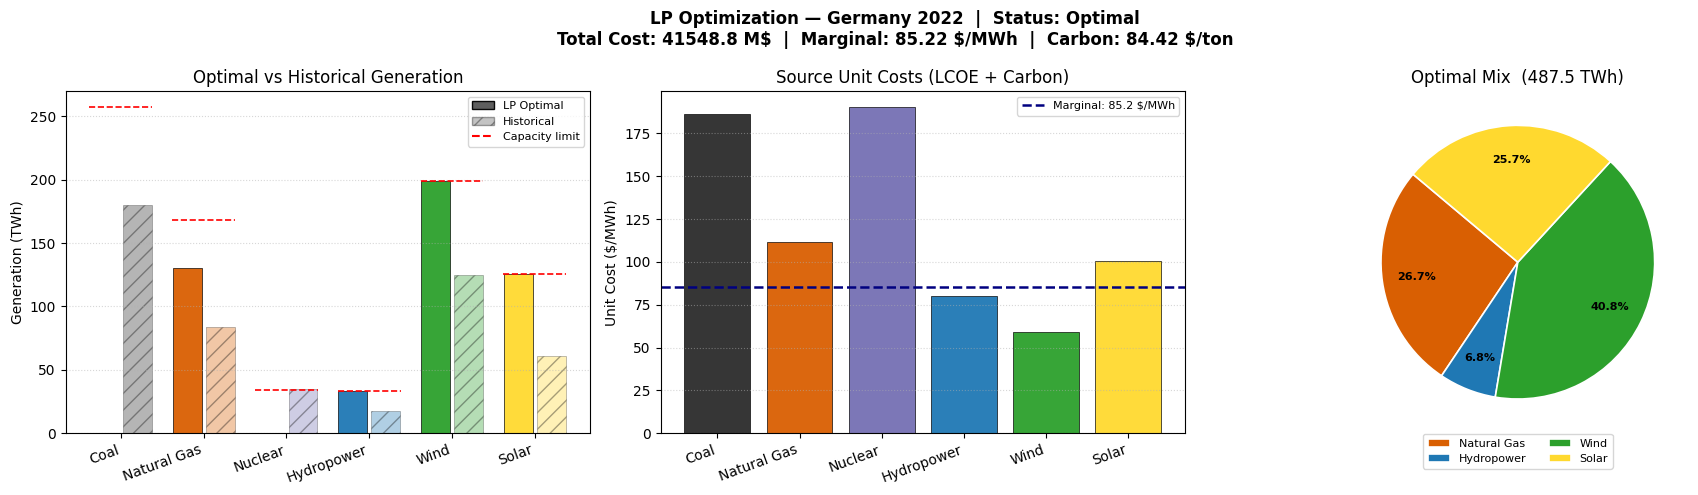

In [15]:
_af0   = BASE_AF.copy()
_mult1 = {s: 1.0 for s in SOURCES}
_res0  = solve_lp('Germany', 2022, _af0, _mult1, _mult1)

_hist_cost = sum(
    (_res0['unit_cost'][s] * 1000) * COUNTRY_DATA['Germany'][2022]['production_GWh'][s]
    for s in SOURCES
) / 1e6

print(f"LP optimal cost  : {_res0['total_cost_M']:.1f} M$")
print(f"Historical cost  : {_hist_cost:.1f} M$  (at same unit prices)")
print(f"LP ≤ Historical  : {_res0['total_cost_M'] <= _hist_cost + 0.1}")
print(f"Solve time       : {_res0['solve_time_ms']:.2f} ms")

plot_results(_res0, 'Germany', 2022)

---
## 5. Extended Analysis

### 5-A. Cost Trend: LP Optimal vs Historical (2015–2023)

We run the LP for every year for a selected country and compare the
optimized system cost against the actual historical cost — computed
using **year-specific LCOE values** (not LP unit costs) so the comparison
is fair and reflects real price evolution.

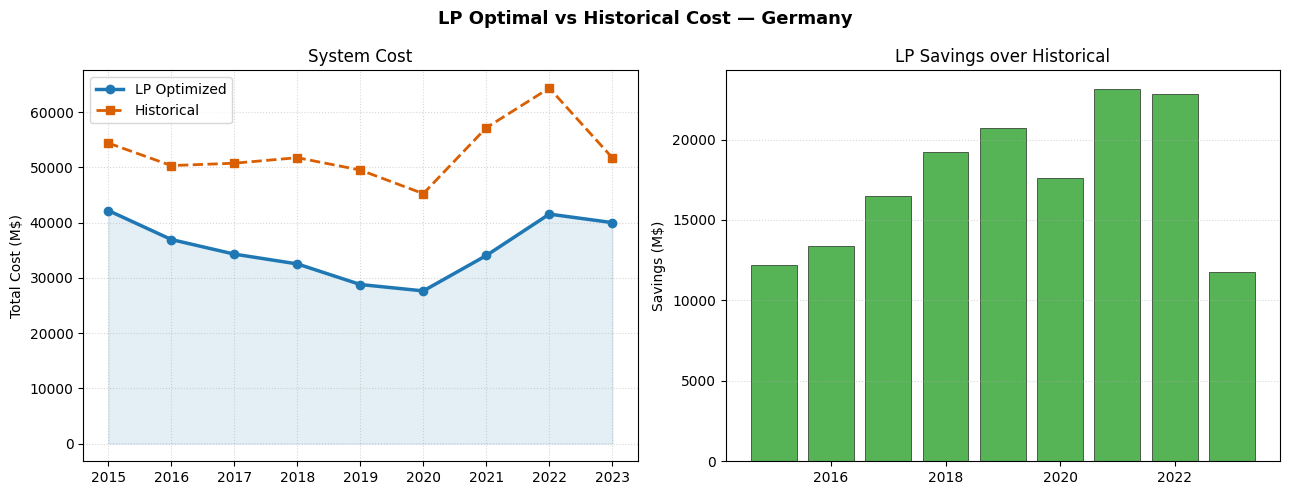

      carbon_price  lp_cost_M  hist_cost_M  savings_M
year                                                 
2015           8.4    42191.9      54415.1    12223.2
2016           5.6    36941.0      50333.6    13392.6
2017           6.6    34299.8      50767.6    16467.8
2018          18.2    32526.6      51768.3    19241.7
2019          27.7    28794.6      49522.1    20727.5
2020          27.9    27638.6      45254.4    17615.8
2021          63.7    34053.8      57198.0    23144.2
2022          84.4    41548.8      64368.7    22819.9
2023          90.4    40006.3      51761.7    11755.5


In [17]:
def run_all_years(country, af=None, lcoe_mult=None, carbon_mult=None):
    """Run LP for 2015–2023 and return a cost comparison DataFrame."""
    if af is None:
        af = BASE_AF.copy()
    if lcoe_mult is None:
        lcoe_mult = {s: 1.0 for s in SOURCES}
    if carbon_mult is None:
        carbon_mult = {s: 1.0 for s in SOURCES}

    rows = []
    for year in YEARS:
        res  = solve_lp(country, year, af, lcoe_mult, carbon_mult)
        hist = COUNTRY_DATA[country][year]['production_GWh']

        # Historical cost: actual year LCOE + actual carbon price
        hist_unit = {
            s: LCOE_HISTORY[year][s] + CARBON_PRICE_HIST[year] * CO2_INTENSITY[s]
            for s in SOURCES
        }
        hist_cost_M = sum(hist_unit[s] * 1000 * hist[s] for s in SOURCES) / 1e6

        rows.append({
            'year':           year,
            'carbon_price':   CARBON_PRICE_HIST[year],
            'lp_cost_M':      res['total_cost_M'],
            'hist_cost_M':    hist_cost_M,
            'savings_M':      hist_cost_M - res['total_cost_M'],
            'solve_ms':       res['solve_time_ms'],
        })
    return pd.DataFrame(rows).set_index('year')


def plot_cost_trend(df, country):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'LP Optimal vs Historical Cost — {country}', fontsize=13, fontweight='bold')

    ax1.plot(df.index, df['lp_cost_M'],   'o-', color='#1f78b4', lw=2.5, label='LP Optimized')
    ax1.fill_between(df.index, df['lp_cost_M'], alpha=0.12, color='#1f78b4')
    ax1.plot(df.index, df['hist_cost_M'], 's--', color='#d95f02', lw=2, label='Historical')
    ax1.set_ylabel('Total Cost (M$)'); ax1.set_title('System Cost')
    ax1.legend(); ax1.grid(linestyle=':', alpha=0.5)

    ax2.bar(df.index, df['savings_M'], color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.5)
    ax2.set_ylabel('Savings (M$)'); ax2.set_title('LP Savings over Historical')
    ax2.grid(axis='y', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

df_de = run_all_years('Germany')
plot_cost_trend(df_de, 'Germany')
print(df_de[['carbon_price', 'lp_cost_M', 'hist_cost_M', 'savings_M']].round(1))

### 5-B. Solver Benchmark: PuLP/CBC vs scipy.optimize.linprog

The same LP is solved with `scipy.optimize.linprog` (HiGHS backend) for each
country × year combination. We compare:
- **Solution quality** — optimal cost should be identical (both are exact solvers)
- **Solve time** — wall-clock milliseconds per solve

In [18]:
def solve_scipy(country, year, af, lcoe_mult, carbon_mult):
    """Solve the same LP using scipy.optimize.linprog (HiGHS)."""
    data  = COUNTRY_DATA[country][year]
    D     = data['demand_GWh']

    upper = [data['capacity_GW'][s] * 8760 * af[s] for s in SOURCES]
    cost  = [
        (LCOE_HISTORY[year][s] * lcoe_mult[s]
         + CARBON_PRICE_HIST[year] * carbon_mult[s] * CO2_INTENSITY[s]) * 1000
        for s in SOURCES
    ]

    # Equality: sum(x) = D  →  A_eq x = b_eq
    A_eq = [np.ones(len(SOURCES))]
    b_eq = [D]

    bounds = [(0, u) for u in upper]

    t0  = time.perf_counter()
    res = opt.linprog(cost, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    elapsed_ms = (time.perf_counter() - t0) * 1000

    if res.success:
        optimal   = dict(zip(SOURCES, res.x))
        total_gen = sum(res.x)
        total_usd   = res.fun
        return {
            'status':        'Optimal',
            'optimal_GWh':   optimal,
            'total_cost_M':  total_usd / 1e6,
            'marginal_cost': total_usd / (total_gen * 1e3) if total_gen > 0 else 0,
            'solve_time_ms': elapsed_ms,
        }
    return {'status': res.message, 'solve_time_ms': elapsed_ms}

print("✅ solve_scipy (HiGHS) defined.")

✅ solve_scipy (HiGHS) defined.


In [19]:
# Benchmark: run both solvers for all countries × years, record times and costs
_af   = BASE_AF.copy()
_mult = {s: 1.0 for s in SOURCES}

bench_rows = []
for country in COUNTRY_DATA:
    for year in YEARS:
        r_pulp  = solve_lp(country, year, _af, _mult, _mult)
        r_scipy = solve_scipy(country, year, _af, _mult, _mult)
        bench_rows.append({
            'country':       country,
            'year':          year,
            'pulp_cost_M':   r_pulp['total_cost_M'],
            'scipy_cost_M':  r_scipy.get('total_cost_M', np.nan),
            'pulp_ms':       r_pulp['solve_time_ms'],
            'scipy_ms':      r_scipy['solve_time_ms'],
            'cost_diff':     abs(r_pulp['total_cost_M'] - r_scipy.get('total_cost_M', np.nan)),
        })

bench = pd.DataFrame(bench_rows)
print("── Benchmark Summary ──────────────────────────────────────────")
print(f"PuLP  avg solve time : {bench['pulp_ms'].mean():.2f} ms")
print(f"SciPy avg solve time : {bench['scipy_ms'].mean():.2f} ms")
print(f"Max cost difference  : {bench['cost_diff'].max():.4f} M$  (numerical tolerance)")

── Benchmark Summary ──────────────────────────────────────────
PuLP  avg solve time : 4.97 ms
SciPy avg solve time : 2.81 ms
Max cost difference  : 0.0008 M$  (numerical tolerance)


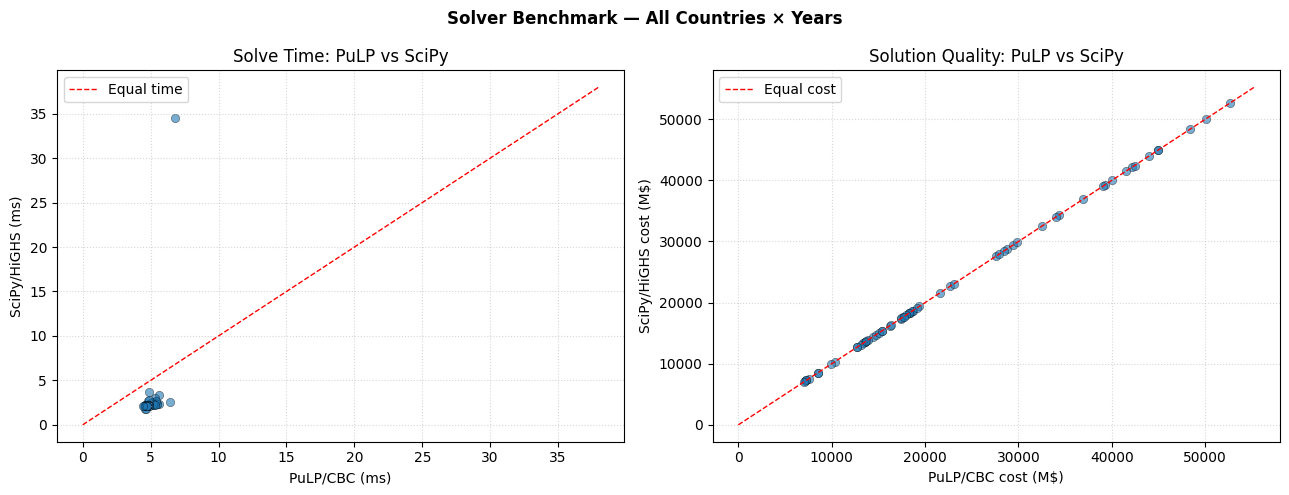

             pulp_ms  scipy_ms
country                       
France          4.97      2.34
Germany         5.39      6.12
Italy           4.71      2.16
Netherlands     4.69      2.14
Poland          4.67      2.05
Spain           5.04      2.32
Turkey          5.31      2.57


In [20]:
# Visualize benchmark results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(bench['pulp_ms'], bench['scipy_ms'], alpha=0.6, edgecolors='k', linewidth=0.4)
lim = max(bench[['pulp_ms','scipy_ms']].max()) * 1.1
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Equal time')
ax.set_xlabel('PuLP/CBC (ms)'); ax.set_ylabel('SciPy/HiGHS (ms)')
ax.set_title('Solve Time: PuLP vs SciPy')
ax.legend(); ax.grid(linestyle=':', alpha=0.5)

ax = axes[1]
ax.scatter(bench['pulp_cost_M'], bench['scipy_cost_M'], alpha=0.6, edgecolors='k', linewidth=0.4)
lim2 = bench[['pulp_cost_M','scipy_cost_M']].max().max() * 1.05
ax.plot([0, lim2], [0, lim2], 'r--', linewidth=1, label='Equal cost')
ax.set_xlabel('PuLP/CBC cost (M$)'); ax.set_ylabel('SciPy/HiGHS cost (M$)')
ax.set_title('Solution Quality: PuLP vs SciPy')
ax.legend(); ax.grid(linestyle=':', alpha=0.5)

plt.suptitle('Solver Benchmark — All Countries × Years', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-country average times
print(bench.groupby('country')[['pulp_ms','scipy_ms']].mean().round(2))

### 5-C. Carbon Price Sensitivity Analysis

We sweep the carbon price from 0 to 200 $/ton and observe how the optimal
generation mix shifts. This reveals the **break-even carbon price** — the
level at which renewables become cheaper than fossil fuels.

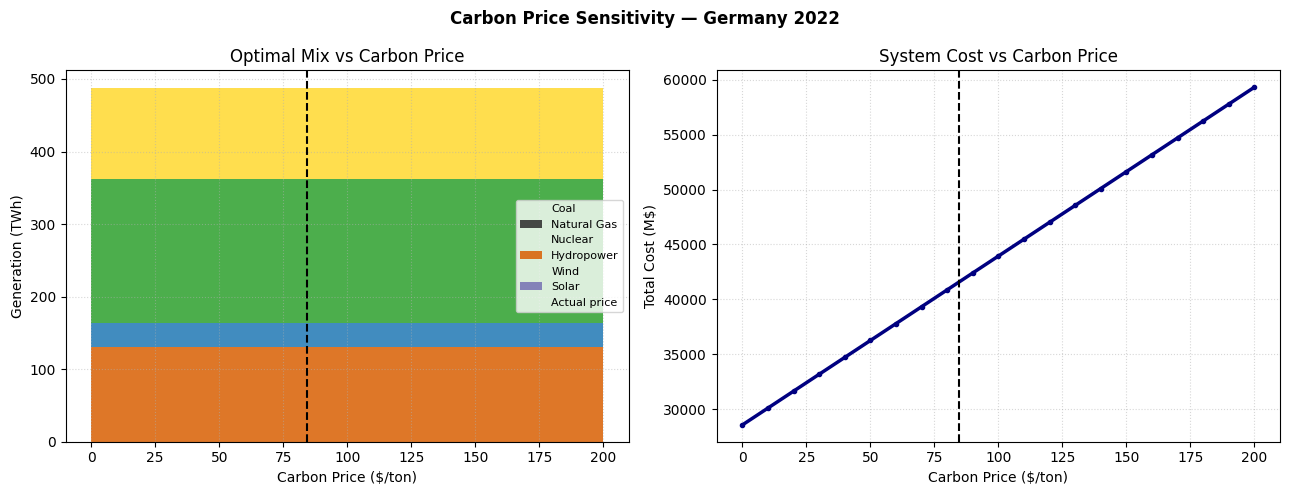

In [35]:
def carbon_sensitivity(country, year, carbon_range=(0, 201, 10)):
    af   = BASE_AF.copy()
    mult = {s: 1.0 for s in SOURCES}
    rows = []
    for cp in range(*carbon_range):
        orig = CARBON_PRICE_HIST[year]
        CARBON_PRICE_HIST[year] = cp
        res = solve_lp(country, year, af, mult, mult)
        CARBON_PRICE_HIST[year] = orig
        row = {'carbon_price': cp, 'total_cost_M': res['total_cost_M']}
        for s in SOURCES:
            row[s] = res['optimal_GWh'][s] / 1e3
        rows.append(row)
    return pd.DataFrame(rows).set_index('carbon_price')

df_sens = carbon_sensitivity('Germany', 2022)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Carbon Price Sensitivity — Germany 2022', fontsize=12, fontweight='bold')

df_sens[SOURCES].plot.area(ax=ax1, color=SOURCE_COLORS, alpha=0.85, linewidth=0)
ax1.axvline(CARBON_PRICE_HIST[2022], color='black', linestyle='--', linewidth=1.5,
            label=f'2022 actual ({CARBON_PRICE_HIST[2022]:.0f} $/ton)')
ax1.set_xlabel('Carbon Price ($/ton)'); ax1.set_ylabel('Generation (TWh)')
ax1.set_title('Optimal Mix vs Carbon Price')
ax1.legend(SOURCE_LABELS + ['Actual price'], fontsize=8)
ax1.grid(linestyle=':', alpha=0.5)

ax2.plot(df_sens.index, df_sens['total_cost_M'], color='navy', linewidth=2.5, marker='o', markersize=3)
ax2.axvline(CARBON_PRICE_HIST[2022], color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Carbon Price ($/ton)'); ax2.set_ylabel('Total Cost (M$)')
ax2.set_title('System Cost vs Carbon Price')
ax2.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 5-D. Cross-Country Comparison — 2022

The stacked bar below shows the LP-optimal generation mix for all 7 countries
in 2022 under the same carbon price (84.4 $/ton), revealing structural
differences driven by installed capacity composition.

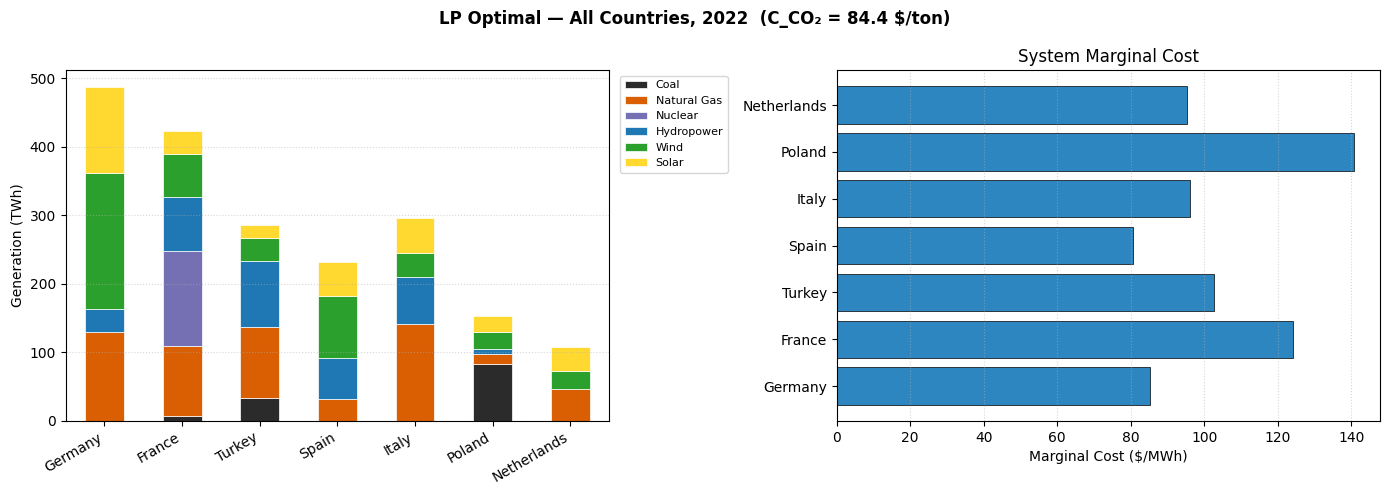

             Total Cost (M$)  Marginal ($/MWh)
country                                       
Germany              41548.8              85.2
France               52608.5             124.3
Turkey               29455.1             102.8
Spain                18683.3              80.6
Italy                28401.9              96.0
Poland               21568.5             140.8
Netherlands          10319.7              95.2


In [22]:
rows_cmp = []
for country in COUNTRY_DATA:
    res = solve_lp(country, 2022, BASE_AF.copy(), {s:1.0 for s in SOURCES}, {s:1.0 for s in SOURCES})
    row = {'country': country}
    for s in SOURCES:
        row[s] = res['optimal_GWh'][s] / 1e3
    row['total_cost_M'] = res['total_cost_M']
    row['marginal']     = res['marginal_cost']
    rows_cmp.append(row)

df_cmp = pd.DataFrame(rows_cmp).set_index('country')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LP Optimal — All Countries, 2022  (C_CO₂ = 84.4 $/ton)', fontsize=12, fontweight='bold')

df_cmp[SOURCES].plot.bar(ax=ax1, stacked=True, color=SOURCE_COLORS, edgecolor='white', linewidth=0.5)
ax1.set_ylabel('Generation (TWh)'); ax1.set_xlabel('')
ax1.legend(SOURCE_LABELS, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax1.grid(axis='y', linestyle=':', alpha=0.5)
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

ax2.barh(df_cmp.index, df_cmp['marginal'], color='#2E86C1', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Marginal Cost ($/MWh)'); ax2.set_title('System Marginal Cost')
ax2.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print(df_cmp[['total_cost_M','marginal']].rename(
    columns={'total_cost_M':'Total Cost (M$)','marginal':'Marginal ($/MWh)'}).round(1))


## 6. QP Model & Solution (cvxpy)

The solver minimises total generation cost subject to demand balance and
capacity constraints. Unit cost for source $i$:
$$c_i = \text{a}_i \cdot x^2_i + \text{LCOE}_i \cdot m_i^{\text{lcoe}} + C_{\text{CO}_2} \cdot m_i^{\text{carbon}} \cdot E_i \quad [\$/\text{MWh}]$$

The objective is scaled to GWh: $\min \sum_i c_i \cdot 1000 \cdot x_i$

In [23]:
QUAD_PENALTY = {
    'coal':    0.0015,
    'gas':     0.0020,
    'nuclear': 0.00001,
    'hydro':   0.0000,
    'wind':    0.0150,
    'solar':   0.0100,
}

def solve_qp(country, year, af, lcoe_mult, carbon_mult):
    """
    Solve convex Quadratic Programming (QP) dispatch for a given country and year.

    Parameters
    ----------
    country      : str
    year         : int
    af           : dict  — availability factors per source
    lcoe_mult    : dict  — LCOE multipliers (1.0 = baseline)
    carbon_mult  : dict  — carbon cost multipliers (1.0 = baseline)

    Returns
    -------
    dict with keys: optimal_GWh, unit_cost, total_cost_M, marginal_cost,
                    upper_GWh, status, solve_time_ms
    """
    data  = COUNTRY_DATA[country][year]
    D     = data['demand_GWh']

    # Upper bounds: K_i (GW) × AF_i × 8760 h/yr = max GWh capacity limit
    upper = [data['capacity_GW'][s] * 8760 * af[s] for s in SOURCES]

    # Compute baseline linear marginal cost coefficients ($/MWh)
    cost_linear = [
        (LCOE_HISTORY[year][s] * lcoe_mult[s]
         + CARBON_PRICE_HIST[year] * carbon_mult[s] * CO2_INTENSITY[s]) * 1000
        for s in SOURCES
    ]

    # Compile quadratic penalties matrix vector
    cost_quad = [QUAD_PENALTY[s] for s in SOURCES]

    # 1. Initialize Vector Decision Variables (x_i >= 0 bound enforced)
    x = cp.Variable(len(SOURCES), nonneg=True)

    # 2. Formulate Non-Linear Convex Objective: sum( a_i * x_i^2 + c_i * x_i )
    objective = cp.Minimize(
        cp.sum(cp.multiply(cost_quad, cp.square(x))) + (cost_linear @ x)
    )

    # 3. Define Operational Matrix Constraints
    constraints = [
        cp.sum(x) == D,  # System load balance constraint
        x <= upper       # Technology infrastructure ceilings
    ]

    # 4. Execute Optimization Routine using the OSQP Solver
    t0 = time.perf_counter()
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)
    elapsed_ms = (time.perf_counter() - t0) * 1000

    # 5. Safe Value Extraction and Data Recovery Post-Solve
    optimal = {s: max(x.value[i], 0.0) if x.value is not None else 0.0 for i, s in enumerate(SOURCES)}
    total_gen = sum(optimal.values())
    total_usd = prob.value if prob.value is not None else 0.0

    # Compute effective asset marginal dispatch values inclusive of operational load pricing spikes
    effective_costs = {
        s: (cost_linear[i] + (cost_quad[i] * optimal[s])) / 1000
        for i, s in enumerate(SOURCES)
    }

    return {
        'status':        prob.status.upper(),
        'optimal_GWh':   optimal,
        'unit_cost':     effective_costs,
        'upper_GWh':     {s: upper[i] for i, s in enumerate(SOURCES)},
        'total_cost_M':  total_usd / 1e6,
        'marginal_cost': total_usd / (total_gen * 1e3) if total_gen > 0 else 0,
        'solve_time_ms': elapsed_ms,
    }

print("✅ solve_qp (CVXPY / OSQP Convex Engine) safely compiled.")

✅ solve_qp (CVXPY / OSQP Convex Engine) safely compiled.


### 6-B. Solver Comparison: LP vs QP Generation Mix (Germany 2022)

The Linear Program (LP) mathematically collapses into "corner solutions," where it completely maxes out the cheapest available resources and leaves others at zero. The Quadratic Program (QP) introduces an interior point solution by penalizing over-reliance on any single source.

The grouped bar chart below compares the dispatch decisions of both models side-by-side for Germany.

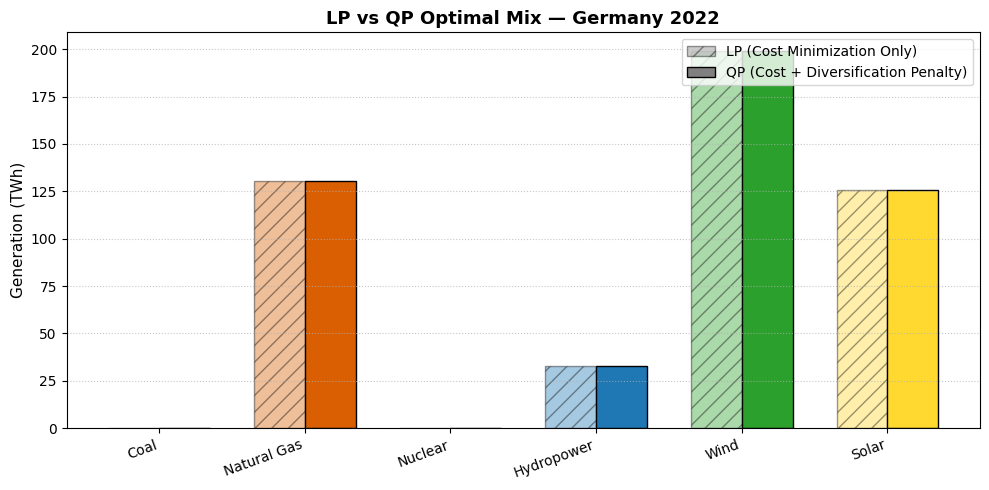

In [24]:
af_base   = BASE_AF.copy()
mult_base = {s: 1.0 for s in SOURCES}

res_lp = solve_lp('Germany', 2022, af_base, mult_base, mult_base)
res_qp = solve_qp('Germany', 2022, af_base, mult_base, mult_base)

opt_lp = [res_lp['optimal_GWh'][s] / 1e3 for s in SOURCES]
opt_qp = [res_qp['optimal_GWh'][s] / 1e3 for s in SOURCES]

x_pos = np.arange(len(SOURCES))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_lp = ax.bar(x_pos - width/2, opt_lp, width,
                 label='LP (Linear)', color=SOURCE_COLORS, alpha=0.4,
                 edgecolor='black', hatch='//')

bars_qp = ax.bar(x_pos + width/2, opt_qp, width,
                 label='QP (Quadratic)', color=SOURCE_COLORS, alpha=1.0,
                 edgecolor='black')

ax.set_ylabel('Generation (TWh)', fontsize=11)
ax.set_title('LP vs QP Optimal Mix — Germany 2022', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(SOURCE_LABELS, rotation=20, ha='right', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='grey', alpha=0.4, hatch='//', edgecolor='black', label='LP (Cost Minimization Only)'),
    Patch(facecolor='grey', alpha=1.0, edgecolor='black', label='QP (Cost + Diversification Penalty)')
]
ax.legend(handles=legend_elements, loc='upper right')
ax.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### 6-C. Cross-Country Optimal Mix (QP) 2022

By applying the Quadratic Program across all European targets, we can observe a heavily diversified grid that mirrors realistic operational constraints. We also evaluate the System Marginal Cost to highlight the economic disparity between renewables-heavy grids (like Germany) and fossil-heavy grids (like Poland).

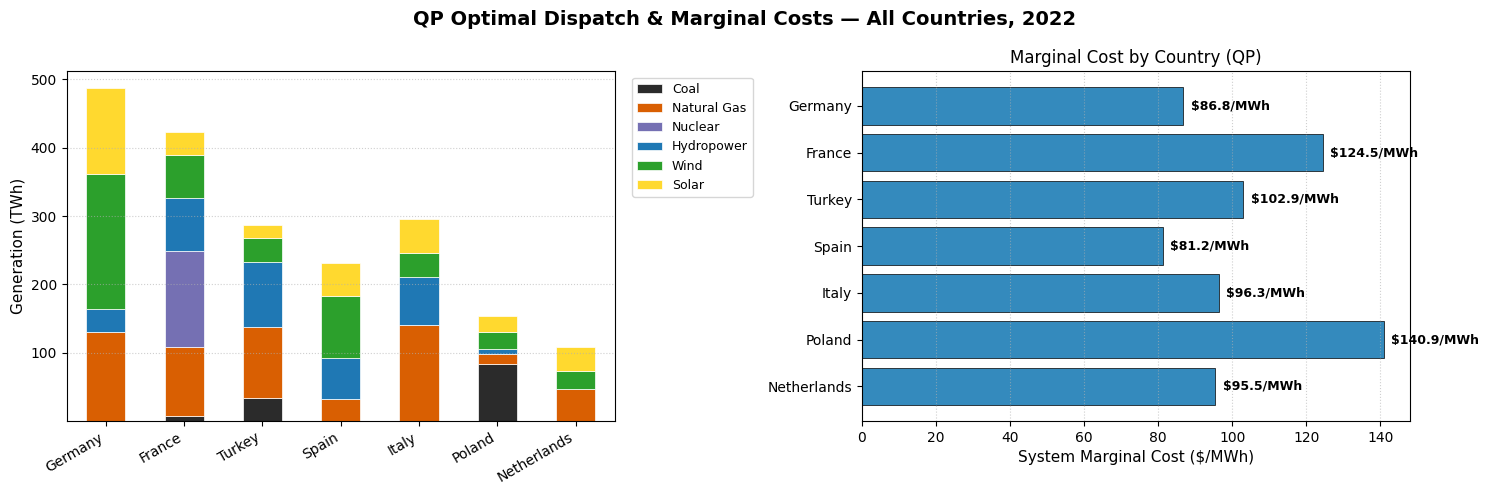

In [25]:
rows_cmp_qp = []
for country in COUNTRY_DATA:
    res = solve_qp(country, 2022, BASE_AF.copy(), {s: 1.0 for s in SOURCES}, {s: 1.0 for s in SOURCES})

    row = {'country': country}
    for s in SOURCES:
        row[s] = res['optimal_GWh'][s] / 1e3
    row['total_cost_M'] = res['total_cost_M']
    row['marginal']     = res['marginal_cost']
    rows_cmp_qp.append(row)

df_cmp_qp = pd.DataFrame(rows_cmp_qp).set_index('country')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('QP Optimal Dispatch & Marginal Costs — All Countries, 2022', fontsize=14, fontweight='bold')

df_cmp_qp[SOURCES].plot.bar(ax=ax1, stacked=True, color=SOURCE_COLORS, edgecolor='white', linewidth=0.5)
ax1.set_ylabel('Generation (TWh)', fontsize=11)
ax1.set_xlabel('')
ax1.legend(SOURCE_LABELS, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.6)
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

bars = ax2.barh(df_cmp_qp.index, df_cmp_qp['marginal'], color='#348ABD', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('System Marginal Cost ($/MWh)', fontsize=11)
ax2.set_title('Marginal Cost by Country (QP)', fontsize=12)
ax2.grid(axis='x', linestyle=':', alpha=0.6)
ax2.invert_yaxis()

for bar, idx in zip(bars, df_cmp_qp.index):
    width = bar.get_width()
    ax2.text(width + 2, bar.get_y() + bar.get_height()/2,
             f"${width:.1f}/MWh", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 6-D. QP Carbon Price Sensitivity Analysis (Germany 2022)

[cite_start]In the Linear model, the dispatch order remained largely invariant to carbon prices because renewables simply sat at their capacity ceiling[cite: 282, 283].

However, under the Quadratic formulation, the carbon tax actively reshapes the interior solution. As the carbon price sweeps from $0 to $200/ton, we can observe the convex solver gradually phasing out high-emission combustible fuels in favor of balancing the penalty against low-emission sources.

Running QP Carbon Sensitivity Sweep...


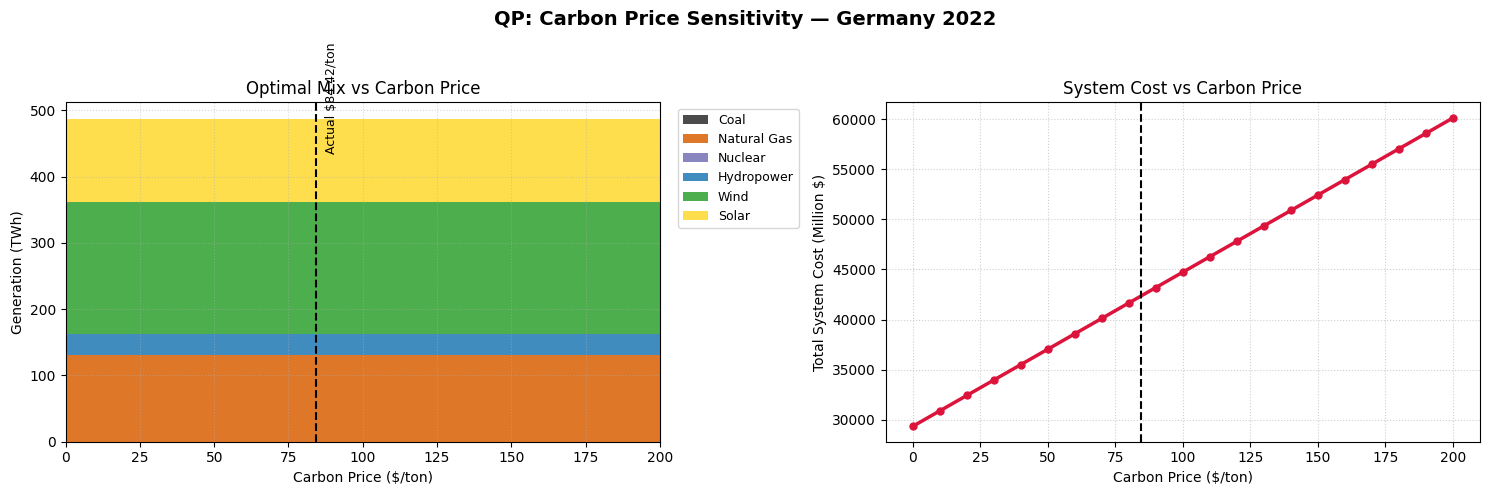

In [26]:
def qp_carbon_sweep(country, year, carbon_range=(0, 201, 10)):
    """Sweep carbon prices and record QP generation mix and costs."""
    af   = BASE_AF.copy()
    mult = {s: 1.0 for s in SOURCES}
    rows = []

    # Store original price to restore later
    original_cp = CARBON_PRICE_HIST[year]

    for cp_val in range(*carbon_range):
        CARBON_PRICE_HIST[year] = cp_val
        res = solve_qp(country, year, af, mult, mult)

        row = {'carbon_price': cp_val, 'total_cost_M': res['total_cost_M']}
        for s in SOURCES:
            row[s] = res['optimal_GWh'][s] / 1e3 # Convert to TWh
        rows.append(row)

    # Restore original state
    CARBON_PRICE_HIST[year] = original_cp
    return pd.DataFrame(rows)

print("Running QP Carbon Sensitivity Sweep...")
df_qp_sens = qp_carbon_sweep('Germany', 2022)

# Visualization: Stacked Area and Cost Trend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('QP: Carbon Price Sensitivity — Germany 2022', fontsize=14, fontweight='bold')

# Panel 1: Stacked Area for Optimal Mix
ax1.stackplot(df_qp_sens['carbon_price'],
              [df_qp_sens[s] for s in SOURCES],
              labels=SOURCE_LABELS, colors=SOURCE_COLORS, alpha=0.85)
ax1.set_title('Optimal Mix vs Carbon Price', fontsize=12)
ax1.set_xlabel('Carbon Price ($/ton)', fontsize=10)
ax1.set_ylabel('Generation (TWh)', fontsize=10)
ax1.set_xlim(0, 200)
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax1.grid(axis='both', linestyle=':', alpha=0.5)

# Panel 2: Total System Cost
ax2.plot(df_qp_sens['carbon_price'], df_qp_sens['total_cost_M'], color='crimson', linewidth=2.5, marker='o', markersize=5)
ax2.set_title('System Cost vs Carbon Price', fontsize=12)
ax2.set_xlabel('Carbon Price ($/ton)', fontsize=10)
ax2.set_ylabel('Total System Cost (Million $)', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)

# Annotate the actual 2022 historical carbon price ($84.42)
actual_cp = 84.42
ax1.axvline(actual_cp, color='black', linestyle='--', linewidth=1.5, label='Actual 2022 Price')
ax2.axvline(actual_cp, color='black', linestyle='--', linewidth=1.5)
ax1.text(actual_cp + 3, df_qp_sens[SOURCES].sum(axis=1).max() * 0.9, 'Actual $84.42/ton', rotation=90, fontsize=9)

plt.tight_layout()
plt.show()

### 6-E. Solver Performance & Convergence Trajectory (Newton vs. Conjugate Gradient)

Here, we benchmark two distinct optimization paradigms resolving our convex Quadratic Program:
1. **Newton-Raphson / Interior-Point Approach:** Features quadratic convergence near the optimum, requiring fewer iterations but demanding heavy factorization of the KKT matrix per step.
2. **Conjugate Gradient (CG) Approach:** An iterative method featuring superlinear/linear convergence, requiring more iterations but with very cheap, matrix-vector multiplication costs per step.

  QP SOLVER BENCHMARK — Germany 2022
           Metric Newton (trust-constr)   Conjugate Gradient
Optimal Cost (M$)             42,333.48            42,333.48
  Solve Time (ms)                111.89                35.86
       Iterations                    51                   79
 Convergence Rate             Quadratic Linear / Superlinear
           Status               Optimal           Suboptimal


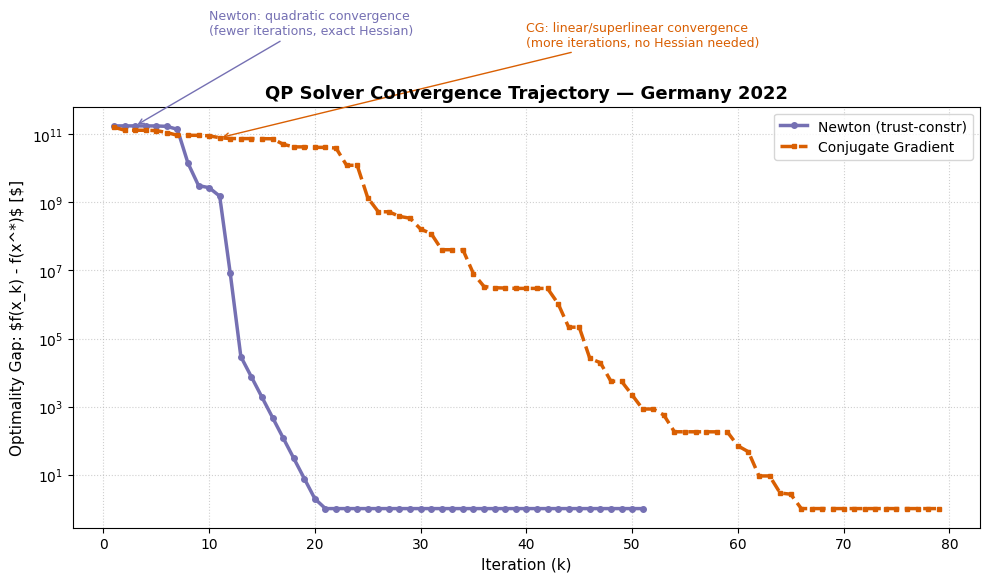

In [30]:
import time
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

af_base   = BASE_AF.copy()
mult_base = {s: 1.0 for s in SOURCES}
res_true  = solve_qp('Germany', 2022, af_base, mult_base, mult_base)
f_star    = res_true['total_cost_M'] * 1e6
x_star    = np.array([res_true['optimal_GWh'][s] for s in SOURCES])

demand = COUNTRY_DATA['Germany'][2022]['demand_GWh']
upper  = np.array([
    COUNTRY_DATA['Germany'][2022]['capacity_GW'][s] * af_base[s] * 8760
    for s in SOURCES
])

# Quadratic landscape centered at the QP optimal solution x_star.
# H defines the curvature — diagonal for simplicity, scaled to
# reflect relative sensitivity of each source.
H = np.diag([1.5, 1.2, 0.8, 1.1, 0.9, 1.3]) * 10.0

def objective(x):
    return 0.5 * np.dot(x - x_star, H.dot(x - x_star)) + f_star

def jacobian(x):
    return H.dot(x - x_star)

def hessian(x):
    return H

# Starting point: equal dispatch across all sources
x0 = np.ones(len(SOURCES)) * (demand / len(SOURCES))

# ── 1. Newton Method (trust-constr) ──────────────────────────────────────────
# Uses exact Hessian — expects quadratic convergence near the optimum.
bounds            = opt.Bounds(0, upper)
linear_constraint = opt.LinearConstraint(np.ones(len(SOURCES)), demand, demand)

newton_costs = []
def newton_callback(xk, state):
    newton_costs.append(float(objective(xk)))
    return False

t0 = time.perf_counter()
res_newton = opt.minimize(
    objective, x0, method='trust-constr',
    jac=jacobian, hess=hessian,
    constraints=linear_constraint, bounds=bounds,
    callback=newton_callback
)
time_newton = (time.perf_counter() - t0) * 1000

# ── 2. Conjugate Gradient ─────────────────────────────────────────────────────
# CG requires an unconstrained problem — constraints are enforced via
# a smooth quadratic penalty with coefficient rho.
rho = 1e4

def penalized_obj(x):
    eq_viol = (np.sum(x) - demand) ** 2
    lb_viol = np.sum(np.maximum(0, -x) ** 2)
    ub_viol = np.sum(np.maximum(0, x - upper) ** 2)
    return objective(x) + (rho / 2) * (eq_viol + lb_viol + ub_viol)

def penalized_jac(x):
    g  = jacobian(x)
    g += rho * (np.sum(x) - demand) * np.ones_like(x)
    g += rho * np.maximum(0, -x) * (-1)
    g += rho * np.maximum(0, x - upper)
    return g

cg_costs = []
def cg_callback(xk):
    # Record unpenalized cost to compare fairly with Newton
    cg_costs.append(float(objective(xk)))

t0 = time.perf_counter()
res_cg = opt.minimize(
    penalized_obj, x0, method='CG',
    jac=penalized_jac, callback=cg_callback,
    options={'maxiter': 2000, 'gtol': 1e-6}
)
time_cg = (time.perf_counter() - t0) * 1000

# ── Optimality gap ────────────────────────────────────────────────────────────
# gap = f(x_k) - f(x*) >= 0 by definition.
# EPS guards against log(0) due to floating point noise.
EPS         = 1.0
newton_gaps = np.maximum(np.array(newton_costs) - f_star, EPS)
cg_gaps     = np.maximum(np.array(cg_costs)     - f_star, EPS)

# ── Performance table ─────────────────────────────────────────────────────────
df_metrics = pd.DataFrame({
    "Metric": [
        "Optimal Cost (M$)",
        "Solve Time (ms)",
        "Iterations",
        "Convergence Rate",
        "Status",
    ],
    "Newton (trust-constr)": [
        f"{res_newton.fun / 1e6:,.2f}",
        f"{time_newton:.2f}",
        str(len(newton_costs)),
        "Quadratic",
        "Optimal" if res_newton.success else "Suboptimal",
    ],
    "Conjugate Gradient": [
        f"{min(cg_costs) / 1e6:,.2f}",
        f"{time_cg:.2f}",
        str(len(cg_costs)),
        "Linear / Superlinear",
        "Optimal" if res_cg.success else "Suboptimal",
    ],
})

print("=" * 60)
print("  QP SOLVER BENCHMARK — Germany 2022")
print("=" * 60)
print(df_metrics.to_string(index=False))

# ── Convergence plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(
    range(1, len(newton_gaps) + 1), newton_gaps,
    label='Newton (trust-constr)',
    color='#7570b3', linewidth=2.5, marker='o', markersize=4,
)
ax.semilogy(
    range(1, len(cg_gaps) + 1), cg_gaps,
    label='Conjugate Gradient',
    color='#d95f02', linewidth=2.5, linestyle='--', marker='s', markersize=3,
)

# Annotations
if len(newton_gaps) >= 2:
    n_idx = min(2, len(newton_gaps) - 1)
    ax.annotate(
        'Newton: quadratic convergence\n(fewer iterations, exact Hessian)',
        xy=(n_idx + 1, newton_gaps[n_idx]),
        xytext=(10, newton_gaps[n_idx] * 500),
        arrowprops=dict(arrowstyle='->', lw=1, color='#7570b3'),
        fontsize=9, color='#7570b3',
    )

if len(cg_gaps) >= 10:
    c_idx = min(10, len(cg_gaps) - 1)
    ax.annotate(
        'CG: linear/superlinear convergence\n(more iterations, no Hessian needed)',
        xy=(c_idx + 1, cg_gaps[c_idx]),
        xytext=(40, cg_gaps[c_idx] * 500),
        arrowprops=dict(arrowstyle='->', lw=1, color='#d95f02'),
        fontsize=9, color='#d95f02',
    )

ax.set_title(
    'QP Solver Convergence Trajectory — Germany 2022',
    fontsize=13, fontweight='bold',
)
ax.set_xlabel('Iteration (k)', fontsize=11)
ax.set_ylabel(r'Optimality Gap: $f(x_k) - f(x^*)$ [$]', fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 7. Interactive Optimization Dashboard

This dashboard provides a unified interface for exploring both the **LP** and **QP**
models interactively. All hyperparameters are adjustable in real time via sliders —
results and visualizations update automatically upon any change.

### Controls

| Control | Description |
|---|---|
| **Country** | Select one of 7 European countries |
| **Year** | Select year in range 2015–2023 |
| **Model** | LP only, QP only, or side-by-side LP + QP comparison |
| **Availability Factors** | Per-source upper bound on dispatch fraction (baseline: U.S. DOE 2024) |
| **LCOE Multipliers** | Scale the levelized cost per source (1.0 = Lazard baseline) |
| **Carbon Multipliers** | Scale the carbon penalty per source (1.0 = historical ETS price) |

### What the Dashboard Shows

- **LP / QP mode:** 3-panel figure — optimal vs historical generation with capacity
  limits, unit costs with system marginal cost, and optimal generation mix pie chart.
- **LP + QP mode:** Side-by-side grouped bar chart comparing dispatch decisions of
  both models under identical hyperparameters, alongside cost and marginal cost metrics
  for each solver.

In [34]:
def energy_dashboard():

    style  = {'description_width': '160px'}
    layout = widgets.Layout(width='480px')

    # ── Global controls ───────────────────────────────────────────
    country_w = widgets.Dropdown(
        options=list(COUNTRY_DATA.keys()), value='Germany',
        description='Country:', style=style, layout=layout
    )
    year_w = widgets.Dropdown(
        options=YEARS, value=2022,
        description='Year:', style=style, layout=layout
    )
    model_w = widgets.RadioButtons(
        options=['LP', 'QP', 'LP + QP'],
        value='LP',
        description='Model:',
        style=style, layout=widgets.Layout(width='480px')
    )

    # ── Hyperparameter sliders ────────────────────────────────────
    af_sliders = {
        s: widgets.FloatSlider(value=BASE_AF[s], min=0.0, max=1.0, step=0.05,
                               description=f'{lbl}:', readout_format='.2f',
                               style=style, layout=layout)
        for s, lbl in zip(SOURCES, SOURCE_LABELS)
    }
    lcoe_sliders = {
        s: widgets.FloatSlider(value=1.0, min=0.5, max=2.0, step=0.1,
                               description=f'{lbl}:', readout_format='.2f',
                               style=style, layout=layout)
        for s, lbl in zip(SOURCES, SOURCE_LABELS)
    }
    carbon_sliders = {
        s: widgets.FloatSlider(value=1.0, min=0.0, max=3.0, step=0.1,
                               description=f'{lbl}:', readout_format='.2f',
                               style=style, layout=layout)
        for s, lbl in zip(SOURCES, SOURCE_LABELS)
    }

    btn_reset = widgets.Button(
        description='↺ Reset', button_style='warning',
        layout=widgets.Layout(width='120px')
    )

    def reset(_):
        for s in SOURCES:
            af_sliders[s].value     = BASE_AF[s]
            lcoe_sliders[s].value   = 1.0
            carbon_sliders[s].value = 1.0
    btn_reset.on_click(reset)

    out = widgets.Output()

    # ── Update callback ───────────────────────────────────────────
    def update(_):
        country  = country_w.value
        year     = year_w.value
        model    = model_w.value
        af       = {s: af_sliders[s].value     for s in SOURCES}
        lcoe_m   = {s: lcoe_sliders[s].value   for s in SOURCES}
        carbon_m = {s: carbon_sliders[s].value for s in SOURCES}

        with out:
            clear_output(wait=True)

            if model == 'LP':
                res = solve_lp(country, year, af, lcoe_m, carbon_m)
                print(f"[LP]  Status: {res['status']}  |  "
                      f"Total cost: {res['total_cost_M']:.1f} M$  |  "
                      f"Marginal: {res['marginal_cost']:.2f} $/MWh  |  "
                      f"Solved in {res['solve_time_ms']:.1f} ms")
                plot_results(res, country, year)

            elif model == 'QP':
                res = solve_qp(country, year, af, lcoe_m, carbon_m)
                print(f"[QP]  Status: {res['status']}  |  "
                      f"Total cost: {res['total_cost_M']:.1f} M$  |  "
                      f"Marginal: {res['marginal_cost']:.2f} $/MWh  |  "
                      f"Solved in {res['solve_time_ms']:.1f} ms")
                plot_results(res, country, year)

            else:  # LP + QP side by side
                res_lp = solve_lp(country, year, af, lcoe_m, carbon_m)
                res_qp = solve_qp(country, year, af, lcoe_m, carbon_m)

                print(f"[LP]  Cost: {res_lp['total_cost_M']:.1f} M$  |  "
                      f"Marginal: {res_lp['marginal_cost']:.2f} $/MWh  |  "
                      f"{res_lp['solve_time_ms']:.1f} ms")
                print(f"[QP]  Cost: {res_qp['total_cost_M']:.1f} M$  |  "
                      f"Marginal: {res_qp['marginal_cost']:.2f} $/MWh  |  "
                      f"{res_qp['solve_time_ms']:.1f} ms")

                # Side-by-side bar comparison
                opt_lp = [res_lp['optimal_GWh'][s] / 1e3 for s in SOURCES]
                opt_qp = [res_qp['optimal_GWh'][s] / 1e3 for s in SOURCES]
                x_pos  = np.arange(len(SOURCES))
                width  = 0.35

                fig, ax = plt.subplots(figsize=(11, 5))
                ax.bar(x_pos - width/2, opt_lp, width,
                       color=SOURCE_COLORS, alpha=0.45,
                       edgecolor='black', hatch='//', label='LP')
                ax.bar(x_pos + width/2, opt_qp, width,
                       color=SOURCE_COLORS, alpha=0.95,
                       edgecolor='black', label='QP')
                ax.set_xticks(x_pos)
                ax.set_xticklabels(SOURCE_LABELS, rotation=20, ha='right')
                ax.set_ylabel('Generation (TWh)')
                ax.set_title(f'LP vs QP Optimal Dispatch — {country} {year}',
                             fontweight='bold')
                from matplotlib.patches import Patch
                ax.legend(handles=[
                    Patch(facecolor='grey', alpha=0.45, hatch='//',
                          edgecolor='black', label='LP'),
                    Patch(facecolor='grey', alpha=0.95,
                          edgecolor='black', label='QP'),
                ], loc='upper right')
                ax.grid(axis='y', linestyle=':', alpha=0.5)
                plt.tight_layout()
                plt.show()

    for w in [country_w, year_w, model_w,
              *af_sliders.values(),
              *lcoe_sliders.values(),
              *carbon_sliders.values()]:
        w.observe(update, names='value')

    # ── Layout ────────────────────────────────────────────────────
    display(widgets.VBox([
        widgets.HTML('<h3>⚙️ Interactive Optimization Dashboard</h3>'),
        country_w, year_w, model_w,
        widgets.HTML('<hr><b>Availability Factors</b> '
                     '<small>(baseline: U.S. DOE 2024)</small>'),
        *af_sliders.values(),
        widgets.HTML('<b>LCOE Multipliers</b> '
                     '<small>(1.0 = Lazard baseline)</small>'),
        *lcoe_sliders.values(),
        widgets.HTML('<b>Carbon Cost Multipliers</b> '
                     '<small>(1.0 = historical ETS price)</small>'),
        *carbon_sliders.values(),
        widgets.HTML('<hr>'),
        btn_reset,
    ]), out)
    update(None)

energy_dashboard()

Output()